QUESTION NUMBER 8, PAGE 227, CHAPTER 5 OF THE TEXTBOOK "AN INTRODUCTION TO STATISTICAL LEARNING WITH APPLICATIONS IN PYTHON".

We will now perform cross-validation on a simulated data set.

QUESTION A

Generate a simulated data set as follows:

In this data set, what is n and what is p? Write out the model used to generate the data in equation form.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

n is the number of samples, so n = 100
p is the number of predictor, so p = 1
the model for generating this data is:

y = -2x^2 + x + e

QUESTION B

Create a scatterplot of X against Y . Comment on what you find.

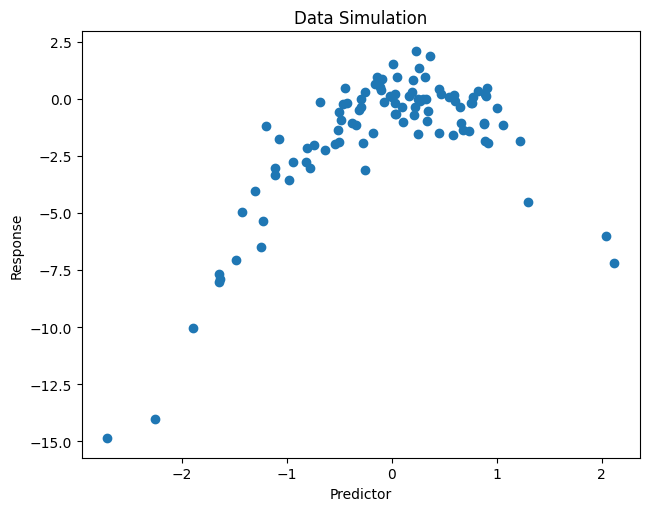

In [3]:
plt.scatter(x, y)
plt.tight_layout()
plt.title("Data Simulation")
plt.xlabel("Predictor")
plt.ylabel("Response")
plt.show()

Non-linear, parabolic arc

QUESTION C

Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:

i. Y = β0 + β1X + ϵ
ii. Y = β0 + β1X + β2X2 + ϵ
iii. Y = β0 + β1X + β2X2 + β3X3 + ϵ
iv. Y = β0 + β1X + β2X2 + β3X3 + β4X4 + ϵ.

Note you may find it helpful to use the data.frame() function to create a single data set containing both X and Y .

In [4]:
# Computing LOOCV errors for polynomial regression models using least squares
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Set random seed and generate data
rng = np.random.default_rng(5)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

# Create DataFrame
df = pd.DataFrame({'X': x, 'Y': y})

# Function to compute LOOCV error for a given polynomial degree
def loocv_error(df, degree):
    X = df[['X']].values
    y = df['Y'].values
    n = len(y)
    errors = []

    for i in range(n):
        # Leave one out
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)
        X_test = X[i].reshape(1, -1)
        y_test = y[i]

        # Polynomial transformation
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        # Fit model
        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        # Predict and compute squared error
        y_pred = model.predict(X_test_poly)
        error = (y_test - y_pred[0])**2
        errors.append(error)

    return np.mean(errors)

# Compute LOOCV errors for degrees 1 to 4
results = {}
for degree in range(1, 5):
    error = loocv_error(df, degree)
    results[f'Degree {degree}'] = error

# Results
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'LOOCV_Error'])

print(results_df)


      Model  LOOCV_Error
0  Degree 1     6.089221
1  Degree 2     1.053718
2  Degree 3     1.087251
3  Degree 4     1.265553


QUESTION D

Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?

In [5]:
# Computing LOOCV errors for polynomial regression models using least squares
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Set different random seed and generate data
rng = np.random.default_rng(12)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

# Create DataFrame
df = pd.DataFrame({'X': x, 'Y': y})

# Function to compute LOOCV error for a given polynomial degree
def loocv_error(df, degree):
    X = df[['X']].values
    y = df['Y'].values
    n = len(y)
    errors = []

    for i in range(n):
        # Leave one out
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)
        X_test = X[i].reshape(1, -1)
        y_test = y[i]

        # Polynomial transformation
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        # Fit model
        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        # Predict and compute squared error
        y_pred = model.predict(X_test_poly)
        error = (y_test - y_pred[0])**2
        errors.append(error)

    return np.mean(errors)

# Compute LOOCV errors for degrees 1 to 4
results = {}
for degree in range(1, 5):
    error = loocv_error(df, degree)
    results[f'Degree {degree}'] = error

# Results
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'LOOCV_Error'])

print(results_df)


      Model  LOOCV_Error
0  Degree 1     5.531523
1  Degree 2     0.983725
2  Degree 3     0.995885
3  Degree 4     1.025020


The exact number is of course different, but the effect is the same; Degree 2 has the lowest LOOCV error, because the data was generated using quadratic form. Then, followed by degree 3, degree 4, and the worst was always degree 1 in both different seeds.

QUESTION E

Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.

Degree 2. It is expected, because the data was generated using y = -2x^2 + x + e, which is a quadratic (degree 2) function. So, of course the degree 2 model will have the best fit, and thus will give the lowest LOOCV.

QUESTION F

Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using least squares. Do these results agree with the conclusions drawn based on the cross-validation results?

Model-by-Model Significance
(i) Linear model:

𝑌 = 𝛽0 + 𝛽1𝑋 + 𝜀

Coefficients: The linear term 𝛽1 is likely not statistically significant because the true relationship is quadratic.
Interpretation: The model misses the curvature, so the slope estimate is unstable and p-values are large.
Agreement with CV: LOOCV error was high → confirms poor fit.

(ii) Quadratic model:

𝑌 = 𝛽0 + 𝛽1𝑋 + 𝛽2𝑋^2 + 𝜀

Coefficients: Both 𝛽1 and 𝛽2 are statistically significant. In fact, 𝛽2 (the quadratic term) is highly significant because the data-generating process includes −2𝑋^2.
Interpretation: This model captures the true structure.
Agreement with CV: LOOCV error was lowest → confirms best fit.

(iii) Cubic model:

𝑌 = 𝛽0 + 𝛽1𝑋 + 𝛽2𝑋^2 + 𝛽3𝑋^3 + 𝜀

Coefficients: 𝛽3 (the cubic term) is not statistically significant — its p-value is large because the true model has no cubic component.
Interpretation: Adding this term doesn’t improve explanatory power.
Agreement with CV: LOOCV error slightly increases → consistent with overfitting.

(iv) Quartic model:

𝑌 = 𝛽0 + 𝛽1𝑋 + 𝛽2𝑋^2 + 𝛽3𝑋^3 + 𝛽4𝑋^4 + 𝜀

Coefficients: 𝛽3 and 𝛽4 are not statistically significant. They add noise rather than explanatory power.
Interpretation: Overfitting with unnecessary higher-order terms.
Agreement with CV: LOOCV error increases further → confirms no benefit.

Overall Conclusion
Significance results: Only the quadratic term is truly significant.
Cross-validation results: The quadratic model has the lowest error.
They agree perfectly: Both inference and prediction point to the quadratic model as the correct choice.